In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset> Size: 438MB
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 72B 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-07...
    latitude           float64 8B ...
    longitude          float64 8B ...
    station_latitude   (station) float64 72B ...
    station_longitude  (station) float64 72B ...
Data variables: (12/14)
    u10                (station, valid_time) float32 27MB ...
    v10                (station, valid_time) float32 27MB ...
    d2m                (station, valid_time) float32 27MB ...
    t2m                (station, valid_time) float32 27MB ...
    msl                (station, valid_time) float32 27MB ...
    sst                (station, valid_time) float32 27MB ...
    ...                 ...
    mwd                (station, valid_time) float32 27MB ...
    mwp                (station

In [3]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")
ds_sealevel = ds

In [4]:
ds_recent = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [5]:
ds = ds_recent

In [6]:
from numba import njit
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr
    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

# FAST block-drift mask: EW-quantile (median) + run-length
@njit(cache=True, fastmath=True)
def _block_mask_1d(values, med_thresh, min_run, alpha):
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    m = 0.0                        # EW median estimate (starts near 0 for residuals)
    run = 0                        # consecutive samples with |m| > threshold
    for i in range(n):
        x = values[i]
        if np.isfinite(x):
            # Robbins–Monro quantile update (tau=0.5 -> median)
            m += alpha * (0.5 - (1.0 if x < m else 0.0))
            if np.abs(m) > med_thresh:
                run += 1
                if run == min_run:
                    # backfill the initial block once threshold run is reached
                    start = i - min_run + 1
                    for j in range(start, i + 1):
                        block[j] = True
                elif run > min_run:
                    block[i] = True
            else:
                run = 0
        else:
            run = 0  # NaN breaks the block
    return block
@njit(cache=True, fastmath=True)
def _yrmean_block_mask_1d(values, yr_mean_vals, good_year_vals,
                          mean_abs_thresh, band, min_run):
    """
    Flag contiguous runs that stay near the (shifted) yearly mean, but only
    in years where |yearly mean| > mean_abs_thresh and coverage was 'good'.
    """
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    run = 0
    start = 0
    for i in range(n):
        x = values[i]
        if not np.isfinite(x):
            run = 0
            continue

        if not good_year_vals[i]:
            # year not eligible: reset run
            run = 0
            continue

        ymean = yr_mean_vals[i]
        if not np.isfinite(ymean) or (np.abs(ymean) <= mean_abs_thresh):
            # yearly mean not "shifted" enough
            run = 0
            continue

        # Are we "near" the shifted yearly mean?
        if np.abs(x - ymean) <= band:
            if run == 0:
                start = i
            run += 1
            if run == min_run:
                for j in range(start, i + 1):
                    block[j] = True
            elif run > min_run:
                block[i] = True
        else:
            run = 0
    return block
def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # mean-shift block knobs
    year_mean_abs_thresh: float = 1.0,   # consider a year "shifted" if |year mean| > 1 m
    block_band: float = 0.5,             # samples within ±band of the yearly mean count toward a block
    min_run: int = 60,                   # consecutive samples near the mean to declare a block
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    # --- robust stats (unchanged)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # --- yearly mean and coverage (unchanged)
    present = da.notnull()
    cov_year = present.groupby(f"{dim}.year").mean(dim=dim)         # fraction present per year
    yr_mean  = da.groupby(f"{dim}.year").mean(dim=dim, skipna=True)  # mean per year
    good_year = cov_year > min_frac_year

    # --- NEW: broadcast per-year values back to each timestamp by selecting with a per-sample 'year' indexer
    # Ensure time axis is datetime64
    if not np.issubdtype(ds[dim].dtype, np.datetime64):
        # If your coord isn't datetime64, convert it here (one-time)
        ds = ds.assign_coords({dim: xr.converters.to_datetime64(ds[dim])})
        da = ds[var].astype("float64")

    year_indexer = xr.DataArray(
        ds[dim].dt.year,         # vector of years for every sample along `dim`
        dims=dim,
        coords={dim: ds[dim]}
    )

    # These now have the SAME dims as `da` (broadcasted back from 'year')
    yr_mean_full   = yr_mean.sel(year=year_indexer)
    good_year_full = good_year.sel(year=year_indexer)

    # --- block detector: runs near the shifted yearly mean
    dev_block = xr.apply_ufunc(
        _yrmean_block_mask_1d,
        da,
        yr_mean_full,
        good_year_full,
        xr.DataArray(year_mean_abs_thresh),
        xr.DataArray(block_band),
        xr.DataArray(np.int64(min_run)),
        input_core_dims=[[dim], [dim], [dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        cov_check = cov_year if not extra else cov_year.mean(dim=extra)
        keep_station = (cov_check > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]
# ds: xr.Dataset with a variable named "residual" along dimension "time"
ds_filtered, dev_mask = filter_residual(ds_recent, var="residual", dim="valid_time")
ds = ds_filtered

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/nputils.py:233: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


In [7]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [8]:
ds_engineered = ds_engineered.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [9]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
features_df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
features_df = features_df.dropna(subset=[target])

# ADd bathymetry_stats

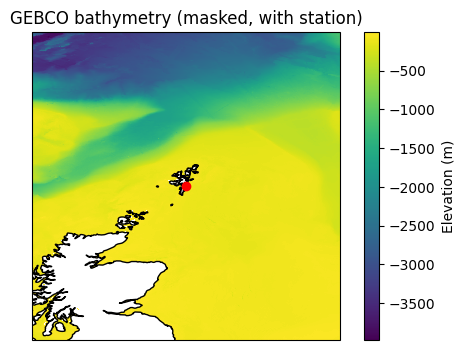

In [10]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['station_latitude'].values
lons = ds_sealevel['station_longitude'].values
station = ds_sealevel['station'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

plot_tile(results["10.0x10.0"][0])

In [11]:
import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Quick, vectorized resize of a GEBCO tile to (H,W) using xarray's interp.
    Works for all numeric vars defined on (lat, lon). Keeps dask laziness.
    """
    # Build uniform target coords spanning the tile extent (ascending)
    lat0, lat1 = float(ds_tile.lat.min()), float(ds_tile.lat.max())
    lon0, lon1 = float(ds_tile.lon.min()), float(ds_tile.lon.max())
    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    # Interpolate all variables defined on (lat, lon)
    return ds_tile.interp(lat=new_lat, lon=new_lon, method="linear")

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

In [12]:
rows = []
for i, (lat, lon) in enumerate(unique_latlon):
    row = {"latitude": lat, "longitude": lon}
    for size in resolutions:
        key = f"{size}x{size}"
        xr_tile = results_128[key][i]
        elev = xr_tile["elevation"].where(xr_tile["elevation"] <= -0.5)
        row[f"tile_{size}"] = elev.values  # 2D array
        # save plotting extent = [lon_min, lon_max, lat_min, lat_max]
        row[f"extent_{size}"] = [
            float(xr_tile["lon"].min()), float(xr_tile["lon"].max()),
            float(xr_tile["lat"].min()), float(xr_tile["lat"].max())
        ]
    rows.append(row)

df = pd.DataFrame(rows)

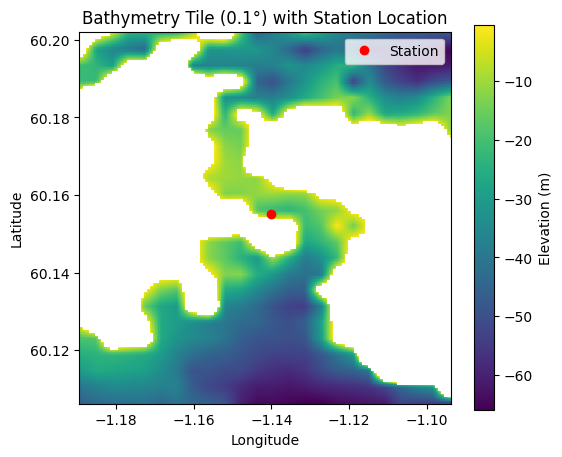

In [13]:

# Select the first row
tile = df["tile_0.1"][0]
lon_min, lon_max, lat_min, lat_max = df["extent_0.1"][0]

station_lon = df["longitude"][0]
station_lat = df["latitude"][0]

plt.figure(figsize=(6, 5))
im = plt.imshow(
    tile,
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower" if lat_min < lat_max else "upper",
    aspect="equal"
)

# Plot the station coordinate
plt.plot(station_lon, station_lat, 'ro', markersize=6, label='Station')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Bathymetry Tile (0.1°) with Station Location")
plt.colorbar(im, label="Elevation (m)")
plt.legend()
plt.show()


In [14]:
import numpy as np

def _station_pixel_indices(st_lat, st_lon, extent, ny, nx):
    lon_min, lon_max, lat_min, lat_max = extent
    dlon = (lon_max - lon_min) / (nx - 1)
    dlat = (lat_max - lat_min) / (ny - 1)

    if lat_max >= lat_min:  # ascending latitude
        iy = int(round((st_lat - lat_min) / dlat))
    else:                   # descending latitude
        dlat = (lat_min - lat_max) / (ny - 1)
        iy = int(round((lat_min - st_lat) / dlat))

    ix = int(round((st_lon - lon_min) / dlon))
    iy = np.clip(iy, 0, ny - 1)
    ix = np.clip(ix, 0, nx - 1)
    return iy, ix, dlat, dlon

def _meters_per_degree(lat_deg):
    lat_rad = np.deg2rad(lat_deg)
    return 111_132.0, 111_320.0 * np.cos(lat_rad)

def tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells=3):
    """
    Stats in a (2r+1)^2 window near station:
      - slope (deg)   [mean of gradient magnitude in deg]
      - roughness std (m)
      - relief p2p (m)
      - mean bathymetry (m) over ocean-only cells (<= -0.5 m)
    """
    if tile is None or np.all(np.isnan(tile)):
        return np.nan, np.nan, np.nan, np.nan

    ny, nx = tile.shape
    iy, ix, dlat_deg, dlon_deg = _station_pixel_indices(st_lat, st_lon, extent, ny, nx)

    y0 = max(0, iy - radius_cells); y1 = min(ny, iy + radius_cells + 1)
    x0 = max(0, ix - radius_cells); x1 = min(nx, ix + radius_cells + 1)

    sub = tile[y0:y1, x0:x1]
    if sub.size == 0 or np.all(np.isnan(sub)):
        return np.nan, np.nan, np.nan, np.nan

    # Ocean-only mask for mean bathy
    sub_ocean = np.where(sub <= -0.5, sub, np.nan)
    mean_bathy = float(np.nanmean(sub_ocean))

    # Pixel spacings (meters) at station latitude
    m_per_deg_lat, m_per_deg_lon = _meters_per_degree(st_lat)
    dy_m = dlat_deg * m_per_deg_lat
    dx_m = dlon_deg * m_per_deg_lon

    # Gradients (fill small NaN gaps just for gradient)
    sub_filled = np.where(np.isnan(sub), np.nanmean(sub), sub) if np.isnan(sub).any() else sub
    gy, gx = np.gradient(sub_filled, dy_m, dx_m)
    slope_mag = np.sqrt(gx**2 + gy**2)           # rise/run
    slope_deg = np.degrees(np.arctan(slope_mag)) # to degrees
    slope_deg = np.where(np.isnan(sub), np.nan, slope_deg)

    slope_local = float(np.nanmean(slope_deg))
    roughness_std = float(np.nanstd(sub))
    relief_p2p = float(np.nanmax(sub) - np.nanmin(sub))

    return slope_local, roughness_std, relief_p2p, mean_bathy

# ---- Apply to all resolutions and add columns ----
radius_cells = 3  # e.g., 7x7 window; tweak as needed

for size in resolutions:  # [0.1, 0.25, 1.0, 3.0, 10.0]
    key = f"{size}"
    tile_col   = f"tile_{key}"
    extent_col = f"extent_{key}"

    df[f"slope_deg_{key}"]      = np.nan
    df[f"roughness_std_{key}"]  = np.nan
    df[f"relief_p2p_{key}"]     = np.nan
    df[f"mean_bathy_{key}"]     = np.nan

    for idx in range(len(df)):
        tile = df.at[idx, tile_col]
        extent = df.at[idx, extent_col]
        st_lat = df.at[idx, "latitude"]
        st_lon = df.at[idx, "longitude"]

        s, rstd, rpp, mb = tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells)
        df.at[idx, f"slope_deg_{key}"]     = s
        df.at[idx, f"roughness_std_{key}"] = rstd
        df.at[idx, f"relief_p2p_{key}"]    = rpp
        df.at[idx, f"mean_bathy_{key}"]    = mb

# Quick peek
print(df.filter(regex=r'^(latitude|longitude|slope_deg_|roughness_std_|relief_p2p_|mean_bathy_)').head())

    latitude  longitude  slope_deg_0.1  roughness_std_0.1  relief_p2p_0.1  \
0  60.155000  -1.140000       2.556153           6.277268       19.727524   
1  61.933000   5.117000       2.249864           3.230781       13.222487   
2  60.154028  -1.140306       3.673631           6.227968       19.388529   
3  60.398046   5.320487       1.550942           2.775370       13.349433   
4  61.933776   5.113310       4.493801           5.673448       16.349896   

   mean_bathy_0.1  slope_deg_0.25  roughness_std_0.25  relief_p2p_0.25  \
0      -14.426290        1.584700            4.874393        19.935015   
1      -19.319174        3.230164           10.342867        52.423476   
2      -11.714256        1.895360            5.546549        19.935015   
3       -8.448963        2.136683            8.918766        36.261825   
4      -11.276415        2.492696            6.556816        23.910919   

   mean_bathy_0.25  ...  relief_p2p_1.0  mean_bathy_1.0  slope_deg_3.0  \
0       -12.564777

In [15]:
features_df = (
    features_df
    .drop(columns=["latitude", "longitude"])
    .rename(columns={
        "station_latitude": "latitude",
        "station_longitude": "longitude"
    })
)

In [16]:
df["latitude"]  = df["latitude"].round(2)
df["longitude"] = df["longitude"].round(2)
features_df["latitude"]  = features_df["latitude"].round(2)
features_df["longitude"] = features_df["longitude"].round(2)

summary_cols = [
    'latitude', 'longitude',
    'slope_deg_0.1','roughness_std_0.1','relief_p2p_0.1','mean_bathy_0.1',
    'slope_deg_0.25','roughness_std_0.25','relief_p2p_0.25','mean_bathy_0.25',
    'slope_deg_1.0','roughness_std_1.0','relief_p2p_1.0','mean_bathy_1.0',
    'slope_deg_3.0','roughness_std_3.0','relief_p2p_3.0','mean_bathy_3.0',
    'slope_deg_10.0','roughness_std_10.0','relief_p2p_10.0','mean_bathy_10.0'
]

summary_df = df[summary_cols]

In [17]:
merged = summary_df.merge(features_df, on=["latitude", "longitude"], how="inner")

# Train on full

In [18]:
# drop NaNs
merged = merged .dropna(subset=["residual"])

In [32]:
RANDOM_SEED=42
# 2) Random 10% sample
sample_frac = 0.01
merged = merged.sample(frac=sample_frac, random_state=RANDOM_SEED)

In [33]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=42

In [34]:
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted( merged["station"].unique()))
perm = rng.permutation(stations)

predictors = [
    col for col in merged.columns
    if col not in ["latitude", "longitude", "valid_time", "residual", "station", "original"]
]

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = merged["station"].isin(train_stn)
m_val   = merged["station"].isin(val_stn)
m_test  = merged["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train =  merged.loc[m_train, X_cols],  merged.loc[m_train, target]
X_val,   y_val   =  merged.loc[m_val,   X_cols],  merged.loc[m_val,   target]
X_test,  y_test  =  merged.loc[m_test,  X_cols],  merged.loc[m_test,  target]

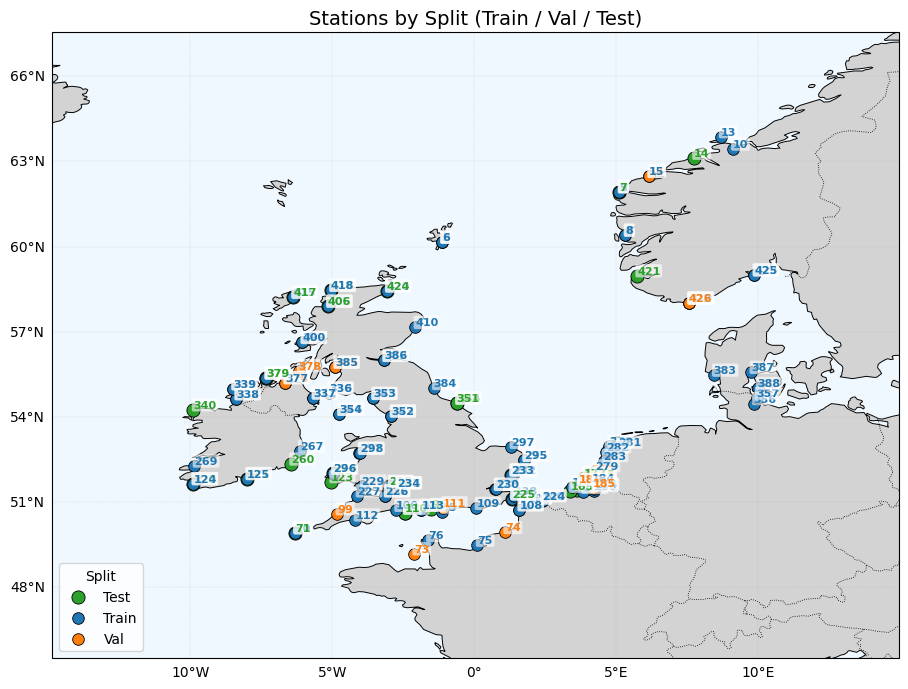

Saved: station_split_map.png


In [35]:
# pip install cartopy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Unique stations with coordinates
st_meta = (
    merged[["station", "latitude", "longitude"]]
    .dropna(subset=["latitude", "longitude"])
    .drop_duplicates(subset=["station"])
    .sort_values("station")
    .reset_index(drop=True)
)

# 2) Add split label
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"

st_meta["split"] = st_meta["station"].apply(split_label)

# 3) Map setup
lon_min, lon_max = st_meta["longitude"].min(), st_meta["longitude"].max()
lat_min, lat_max = st_meta["latitude"].min(),  st_meta["latitude"].max()

# pad the extent a bit
d_lon = (lon_max - lon_min) or 1.0
d_lat = (lat_max - lat_min) or 1.0
pad = 0.25
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 4) Plot by split
colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:green", "unknown": "gray"}
sizes  = {"train": 70, "val": 70, "test": 90, "unknown": 60}  # make test a bit bigger

for split, df_split in st_meta.groupby("split"):
    ax.scatter(
        df_split["longitude"], df_split["latitude"],
        s=sizes.get(split, 70),
        color=colors.get(split, "gray"),
        edgecolor="k",
        linewidth=0.6,
        transform=proj,
        zorder=5,
        label=split.capitalize()
    )

# 5) Optional: label station IDs
label_points = True
if label_points:
    for _, r in st_meta.iterrows():
        ax.text(
            r["longitude"], r["latitude"],
            f'{int(r["station"])}',
            transform=proj,
            fontsize=8, weight="bold",
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
            zorder=6,
            color=colors.get(r["split"], "black")
        )

# legend & title
handles, labels = ax.get_legend_handles_labels()
# deduplicate legend entries
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower left", title="Split")
plt.title("Stations by Split (Train / Val / Test)", fontsize=14)
plt.tight_layout()
plt.savefig("station_split_map.png", dpi=150)
plt.show()

print("Saved: station_split_map.png")

In [36]:
# ---------------------------
# 4) XGBoost quantile models
# ---------------------------
from xgboost import XGBRegressor
from sklearn.metrics import mean_pinball_loss, r2_score, mean_absolute_error
import numpy as np
import joblib

# Quantiles to model (lower, median, upper)
quantiles = [0.10, 0.50, 0.90]

# (Optional) keep your "emphasize extremes" weights — these still work with quantile loss
thr = np.quantile(y_train, 0.95)
w = np.ones_like(y_train, float)
w[y_train >= thr] = 3.0  # try 2–5 first, not 10–50

# Common params (copied from your baseline, with quantile objective)
common_params = dict(
    n_estimators=100,
    learning_rate=0.015,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_lambda=10.0,
    gamma=1.0,
    tree_method="hist",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

# Train a separate model per quantile
q_models = {}
for q in quantiles:
    m = XGBRegressor(
        objective="reg:quantileerror",   # XGBoost quantile / pinball loss
        quantile_alpha=q,
        **common_params,
    )
    # eval_set is optional; leave verbose=False to keep logs clean
    m.fit(X_train, y_train, sample_weight=w, eval_set=[(X_val, y_val)], verbose=False)
    q_models[q] = m

# ---------------------------
# 5) Evaluate
# ---------------------------
def evaluate_point_and_intervals(name, X, y, models_dict):
    """
    Returns dict of preds per quantile + prints pinball loss per quantile,
    plus R2/MAE for the median model as a point forecast.
    """
    # Predict each quantile
    preds = {q: models_dict[q].predict(X) for q in models_dict.keys()}

    # Guard against quantile crossing (ensure q10 <= q50 <= q90)
    # This simple monotonic fix is applied pointwise.
    lower = preds[0.10]
    median = np.maximum(lower, preds[0.50])
    upper = np.maximum(median, preds[0.90])

    # Pinball loss per quantile
    losses = {q: mean_pinball_loss(y, preds[q], alpha=q) for q in preds}
    print(f"{name} Pinball loss | "
          + " | ".join([f"q={q:.2f}: {losses[q]:.4f}" for q in sorted(losses)]))

    # Also report R2/MAE for the median as a point forecast
    r2 = r2_score(y, median)
    mae = mean_absolute_error(y, median)
    print(f"{name} Point (median) | R2: {r2:.4f} | MAE: {mae:.4f}")

    return {"q10": lower, "q50": median, "q90": upper}

print("Performance:")
train_preds = evaluate_point_and_intervals("Train", X_train, y_train, q_models)
val_preds   = evaluate_point_and_intervals(" Val ", X_val,   y_val,   q_models)
test_preds  = evaluate_point_and_intervals("Test ", X_test,  y_test,  q_models)

# For downstream compatibility: if you need a single vector like before,
# use the median as your point prediction.
test_pred_point = test_preds["q50"]

# ---------------------------
# 6) Save models + test predictions
# ---------------------------
# Save all quantile models together
joblib.dump({"models": q_models, "features": X_cols, "quantiles": quantiles},
            "xgb_quantile_models.joblib")

# Save test predictions (median + interval)
out = merged.loc[m_test, ["station", "valid_time", target]].copy()
out["pred_q10"] = test_preds["q10"]
out["pred_q50"] = test_preds["q50"]   # median point forecast
out["pred_q90"] = test_preds["q90"]
out["pi80_width"] = out["pred_q90"] - out["pred_q10"]  # optional diagnostic
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: xgb_quantile_models.joblib")
print("Saved: test_predictions.parquet")

Performance:
Train Pinball loss | q=0.10: 0.0298 | q=0.50: 0.0596 | q=0.90: 0.0317
Train Point (median) | R2: 0.3272 | MAE: 0.1191
 Val  Pinball loss | q=0.10: 0.0254 | q=0.50: 0.0565 | q=0.90: 0.0335
 Val  Point (median) | R2: 0.3108 | MAE: 0.1129
Test  Pinball loss | q=0.10: 0.0281 | q=0.50: 0.0577 | q=0.90: 0.0343
Test  Point (median) | R2: 0.2566 | MAE: 0.1154
Saved: xgb_quantile_models.joblib
Saved: test_predictions.parquet


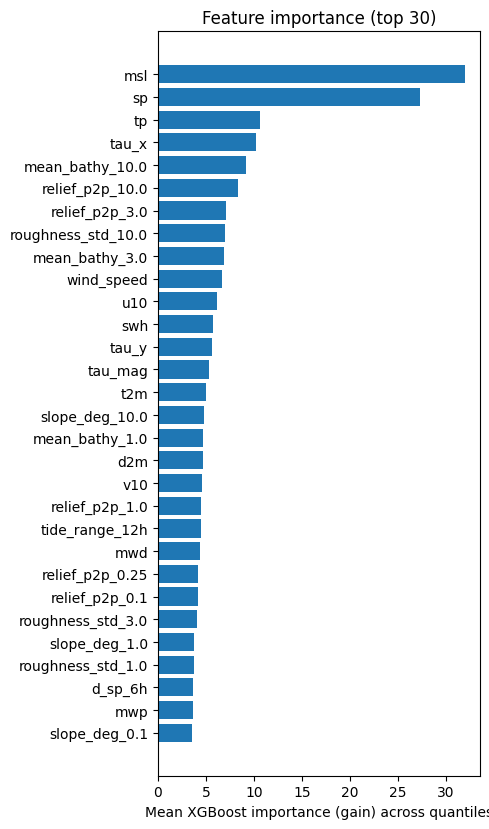

In [37]:
importances = []
for q, model in q_models.items():
    booster = model.get_booster()
    booster.feature_names = list(map(str, X_cols))
    score_dict = booster.get_score(importance_type=importance_type)
    imp = np.array([score_dict.get(str(f), 0.0) for f in X_cols], dtype=float)
    importances.append(imp)

# Average across quantiles
imp_mean = np.mean(importances, axis=0)

order = np.argsort(imp_mean)[::-1]
top_k = 30
order = order[:top_k]

plt.figure(figsize=(5, max(2, 0.28 * len(order))))
plt.barh(np.array(X_cols)[order][::-1], imp_mean[order][::-1])
plt.xlabel(f"Mean XGBoost importance ({importance_type}) across quantiles")
plt.title(f"Feature importance (top {len(order)})")
plt.tight_layout()
plt.show()


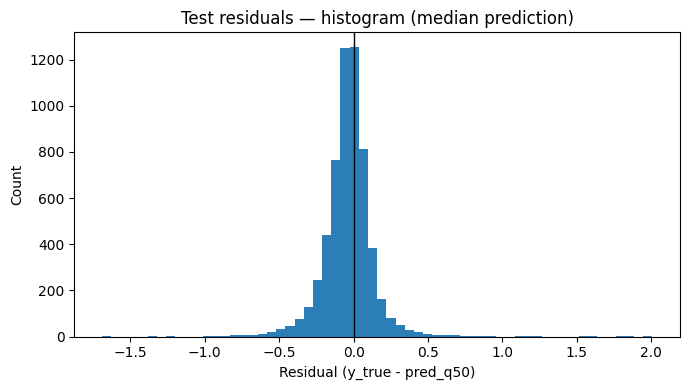

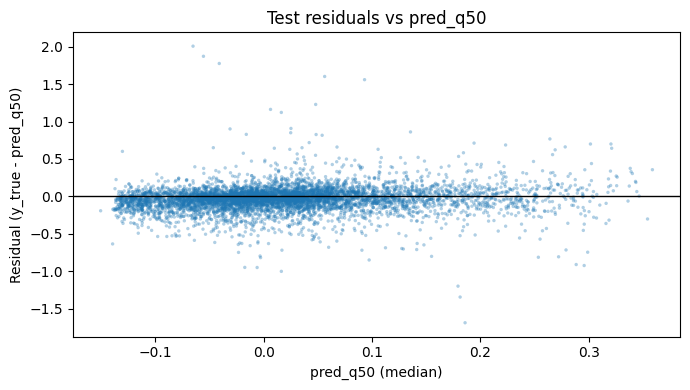

Empirical coverage (q10–q90): 0.854  |  Expected: 0.80


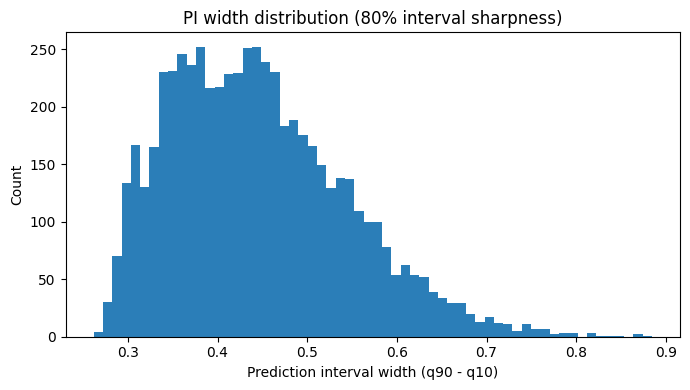

Calibration @ q=0.10: empirical CDF=0.117 (target 0.10)
Calibration @ q=0.50: empirical CDF=0.615 (target 0.50)
Calibration @ q=0.90: empirical CDF=0.970 (target 0.90)


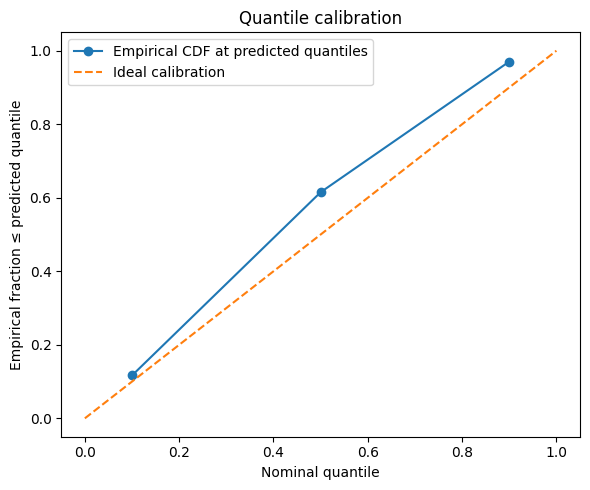

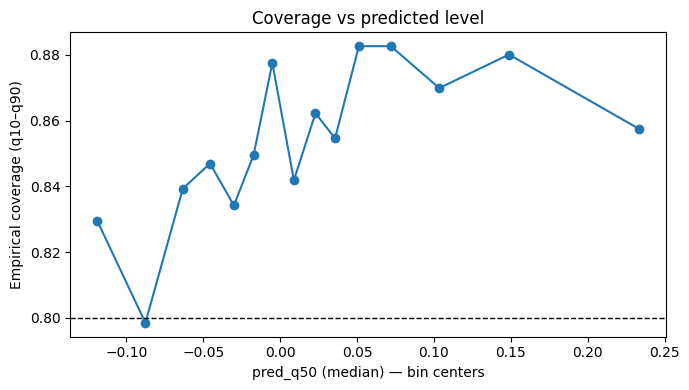

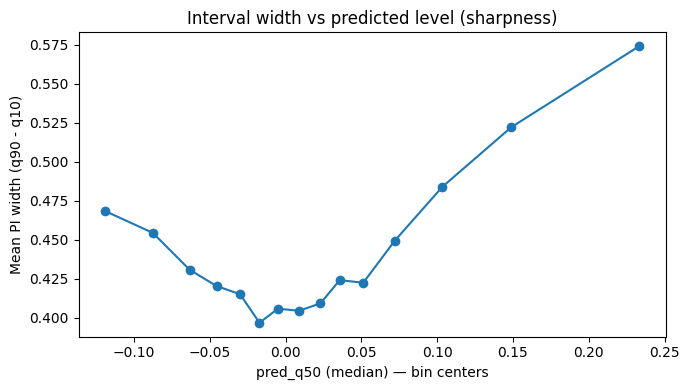

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# --- Prepare: rename to a consistent schema ---
preds = out.rename(columns={target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])

# Use median as point prediction for residual-style plots
preds["y_pred"] = preds["pred_q50"]
preds["residual"] = preds["y_true"] - preds["y_pred"]

# -----------------------------
# A) Residual histogram (vs q50)
# -----------------------------
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - pred_q50)")
plt.ylabel("Count")
plt.title("Test residuals — histogram (median prediction)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# B) Residuals vs median prediction (heteroscedasticity)
# ---------------------------------------------------
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("pred_q50 (median)")
plt.ylabel("Residual (y_true - pred_q50)")
plt.title("Test residuals vs pred_q50")
plt.tight_layout()
plt.show()

# ===================================================
# Extra (recommended for quantiles)
# ===================================================

# C) Interval coverage (80% PI from q10–q90) + width
inside = (preds["y_true"] >= preds["pred_q10"]) & (preds["y_true"] <= preds["pred_q90"])
coverage = inside.mean()
expected_coverage = 0.80
print(f"Empirical coverage (q10–q90): {coverage:.3f}  |  Expected: {expected_coverage:.2f}")

preds["pi80_width"] = preds["pred_q90"] - preds["pred_q10"]

plt.figure(figsize=(7,4))
plt.hist(preds["pi80_width"].dropna(), bins=60, alpha=0.95)
plt.xlabel("Prediction interval width (q90 - q10)")
plt.ylabel("Count")
plt.title("PI width distribution (80% interval sharpness)")
plt.tight_layout()
plt.show()

# D) Calibration at available quantiles (q=0.1, 0.5, 0.9)
qs = [0.10, 0.50, 0.90]
empirical = []
for q in qs:
    col = f"pred_q{int(round(q*100))}"
    emp = (preds["y_true"] <= preds[col]).mean()
    empirical.append(emp)
    print(f"Calibration @ q={q:.2f}: empirical CDF={emp:.3f} (target {q:.2f})")

plt.figure(figsize=(6,5))
plt.plot(qs, empirical, marker="o", label="Empirical CDF at predicted quantiles")
plt.plot([0,1],[0,1], "--", label="Ideal calibration")
plt.xlabel("Nominal quantile")
plt.ylabel("Empirical fraction ≤ predicted quantile")
plt.title("Quantile calibration")
plt.legend()
plt.tight_layout()
plt.show()

# E) Coverage vs. predicted median (are wide intervals where needed?)
#    Bin by pred_q50 and compute coverage + mean width per bin
nbins = 15
bin_edges = np.quantile(preds["y_pred"], np.linspace(0,1,nbins+1))
bin_ids = np.digitize(preds["y_pred"], bin_edges[1:-1], right=True)

bin_cov = []
bin_wid = []
bin_ctr = []
for b in range(nbins):
    m = bin_ids == b
    if m.any():
        bin_cov.append(((preds.loc[m, "y_true"] >= preds.loc[m, "pred_q10"]) & (preds.loc[m, "y_true"] <= preds.loc[m, "pred_q90"])).mean())
        bin_wid.append(preds.loc[m, "pi80_width"].mean())
        bin_ctr.append(np.median(preds.loc[m, "y_pred"]))

plt.figure(figsize=(7,4))
plt.plot(bin_ctr, bin_cov, marker="o")
plt.axhline(expected_coverage, color="k", lw=1, linestyle="--")
plt.xlabel("pred_q50 (median) — bin centers")
plt.ylabel("Empirical coverage (q10–q90)")
plt.title("Coverage vs predicted level")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(bin_ctr, bin_wid, marker="o")
plt.xlabel("pred_q50 (median) — bin centers")
plt.ylabel("Mean PI width (q90 - q10)")
plt.title("Interval width vs predicted level (sharpness)")
plt.tight_layout()
plt.show()



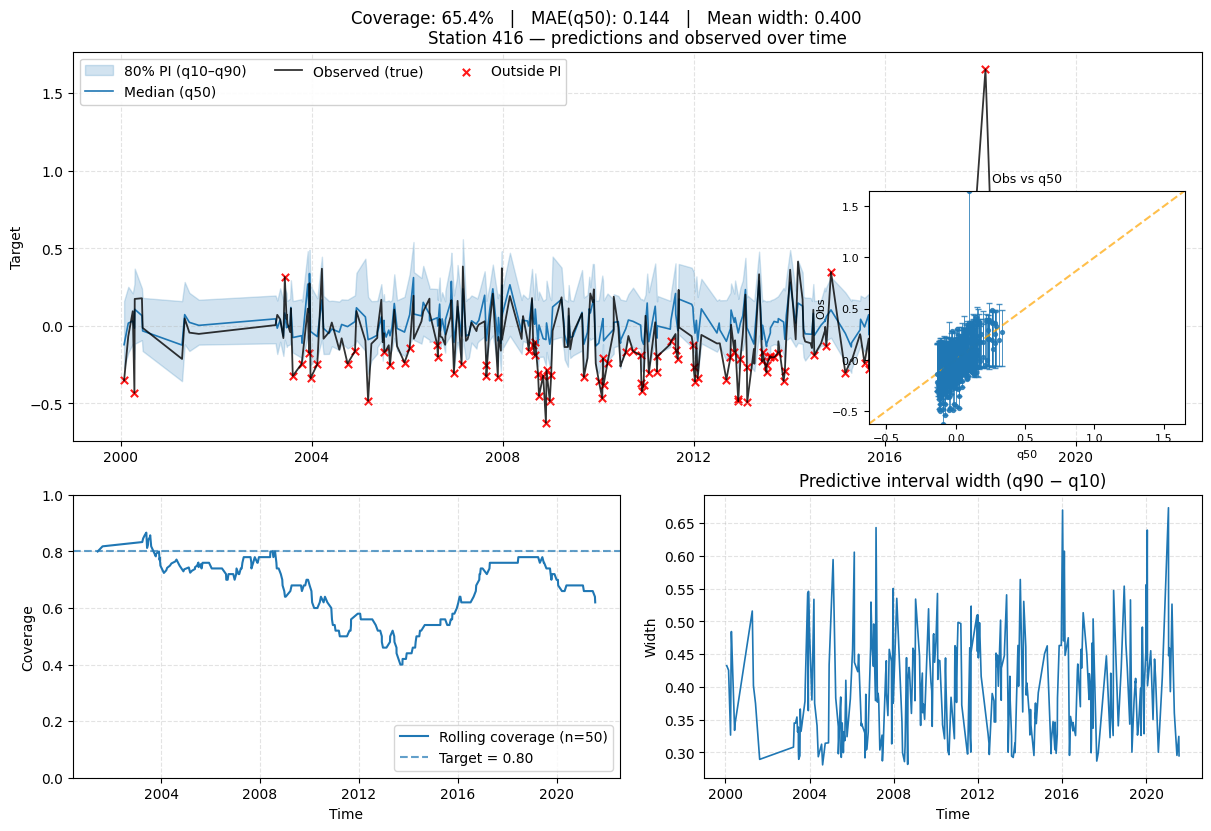

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- assumes df has columns:
# ["station", "valid_time", "y_true", "pred_q10", "pred_q50", "pred_q90"]

def get_station_data(df, station_id):
    g = df[df["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        raise ValueError(f"No test rows for station {station_id}")

    t = pd.to_datetime(g["valid_time"]).to_numpy()
    y_true = g["y_true"].to_numpy()

    preds = {
        0.1: g["pred_q10"].to_numpy(),
        0.5: g["pred_q50"].to_numpy(),
        0.9: g["pred_q90"].to_numpy(),
    }

    # anti-crossing safeguard
    preds[0.5] = np.maximum(preds[0.1], preds[0.5])
    preds[0.9] = np.maximum(preds[0.5], preds[0.9])
    return t, y_true, preds


def plot_station_diagnostics(df, station_id, window=50, sample_scatter=400, figsize=(12, 8)):
    t, y, pr = get_station_data(df, station_id)
    q10, q50, q90 = pr[0.1], pr[0.5], pr[0.9]

    inside = (y >= q10) & (y <= q90)
    cov = float(np.mean(inside))
    mae50 = float(np.mean(np.abs(y - q50)))
    width = (q90 - q10)
    mean_width = float(np.mean(width))

    # rolling coverage
    roll = pd.Series(inside.astype(float), index=pd.to_datetime(t)).rolling(
        window, min_periods=max(10, window // 5)
    ).mean()

    # --- layout
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = GridSpec(2, 2, figure=fig, height_ratios=[2.2, 1.6], width_ratios=[1.1, 1.0])

    # A) Time-series ribbon + observed series
    axA = fig.add_subplot(gs[0, :])
    axA.fill_between(t, q10, q90, color="C0", alpha=0.20, label="80% PI (q10–q90)")
    axA.plot(t, q50, color="C0", lw=1.2, label="Median (q50)")
    axA.plot(t, y, color="black", lw=1.3, alpha=0.8, label="Observed (true)")  # <--- added line
    axA.scatter(t[~inside], y[~inside], s=28, alpha=0.9, marker="x", color="red", label="Outside PI")
    axA.set_ylabel("Target")
    axA.grid(True, ls="--", alpha=0.35)
    axA.legend(loc="upper left", ncol=3, framealpha=0.9)
    axA.set_title(f"Station {station_id} — predictions and observed over time")

    # B) Rolling coverage
    axB = fig.add_subplot(gs[1, 0])
    axB.plot(roll.index, roll.values, lw=1.5, label=f"Rolling coverage (n={window})")
    axB.axhline(0.80, ls="--", alpha=0.7, label="Target = 0.80")
    axB.set_ylim(0, 1)
    axB.set_ylabel("Coverage")
    axB.set_xlabel("Time")
    axB.grid(True, ls="--", alpha=0.35)
    axB.legend(loc="lower right")

    # C) Interval width
    axC = fig.add_subplot(gs[1, 1])
    axC.plot(t, width, lw=1.2)
    axC.set_title("Predictive interval width (q90 − q10)")
    axC.set_ylabel("Width")
    axC.set_xlabel("Time")
    axC.grid(True, ls="--", alpha=0.35)

    # D) Inset scatter (Obs vs Predicted median)
    axD = inset_axes(axA, width="28%", height="60%", loc="lower right", borderpad=1.2)
    n = len(y)
    idx = np.random.choice(n, min(sample_scatter, n), replace=False)
    yerr_low = np.clip(y[idx] - q10[idx], a_min=0, a_max=None)
    yerr_high = np.clip(q90[idx] - y[idx], a_min=0, a_max=None)
    axD.errorbar(
        q50[idx],
        y[idx],
        yerr=[yerr_low, yerr_high],
        fmt="o",
        ms=2.8,
        lw=0.7,
        alpha=0.8,
        capsize=2,
    )
    lo = float(np.nanmin([y.min(), q50.min()]))
    hi = float(np.nanmax([y.max(), q50.max()]))
    axD.plot([lo, hi], [lo, hi], ls="--", alpha=0.7, color="orange")
    axD.set_xlim(lo, hi)
    axD.set_ylim(lo, hi)
    axD.set_title("Obs vs q50", fontsize=9)
    axD.set_xlabel("q50", fontsize=8)
    axD.set_ylabel("Obs", fontsize=8)
    axD.tick_params(labelsize=8)

    # Figure title with summary metrics
    fig.suptitle(
        f"Coverage: {cov:.1%}   |   MAE(q50): {mae50:.3f}   |   Mean width: {mean_width:.3f}",
        y=1.02,
        fontsize=12,
    )
    plt.show()


# ---- Example usage ----
station_id = df["station"].iloc[0]
plot_station_diagnostics(df, station_id, window=50)


🟦 Top Panel — Predictions Over Time

Blue band: The model’s 80% prediction interval (q10–q90) — the range in which the model expects the true value to fall 80% of the time.

Blue line: The predicted median (q50) — the model’s central (most likely) estimate.

Orange dots: Observations that fell inside the 80% interval.

Green Xs: Observations that fell outside the 80% interval (under- or over-predicted).

Inset plot (“Obs vs q50”): A scatter comparing predicted medians vs actuals, with error bars showing the 80% interval for each point. The dashed orange line is the 1:1 (perfect) line.


🟩 Bottom Left — Rolling Coverage
Shows how often the observed value actually landed inside the 80% interval, using a rolling window (e.g., 50 samples).

The dashed horizontal line at 0.8 is the target coverage (ideal calibration).

The blue line below it means underconfident intervals (too narrow); above means overconfident (too wide).


🟨 Bottom Right — Predictive Interval Width

Shows how wide the model’s 80% prediction intervals are over time.

Smaller width = more confident predictions; spikes = times when the model was uncertain

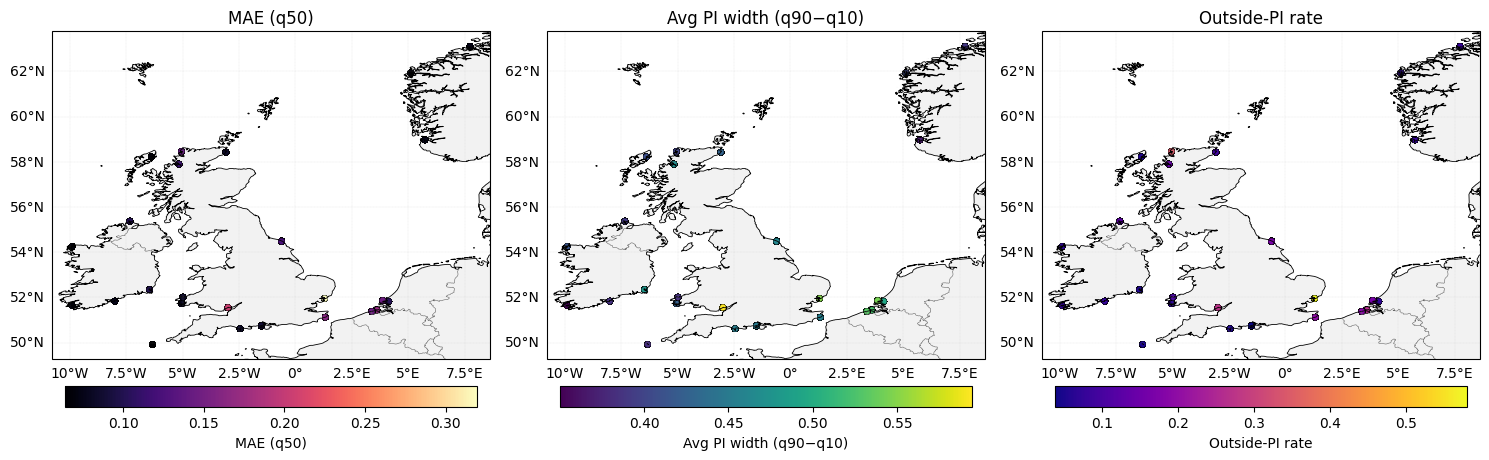

In [ ]:
# =========================
# 1) Compute station metrics
# =========================
import numpy as np
import pandas as pd

def compute_station_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Expects columns:
      ['station','valid_time','y_true','pred_q10','pred_q50','pred_q90']
    Returns one row per station with MAE(q50), average PI width, and outside rate.
    """
    g = df.copy()
    # ensure datetimes if you need them later (not required here)
    g["valid_time"] = pd.to_datetime(g["valid_time"])
    # robust interval: prevent negative width if any crossing slipped through
    g["pi_width"] = (g["pred_q90"] - g["pred_q10"]).clip(lower=0)
    g["abs_err_q50"] = (g["y_true"] - g["pred_q50"]).abs()
    g["inside"] = (g["y_true"] >= g["pred_q10"]) & (g["y_true"] <= g["pred_q90"])

    by_station = g.groupby("station", as_index=False).agg(
        mae_q50=("abs_err_q50", "mean"),
        avg_width=("pi_width", "mean"),
        outside_rate=("inside", lambda s: 1.0 - float(s.mean())),
        n_obs=("y_true", "size")
    )
    return by_station

station_metrics = compute_station_metrics(df)
station_metrics.head()

# ==================================
# 2) Merge with features for lat/lon
# ==================================
# Expect features_df to contain at least: ['station', 'lat', 'lon'].
# If your columns are named 'latitude'/'longitude', they are normalized here.
feat = features_df.copy()

# normalize column names if needed
if "latitude" in feat.columns and "lat" not in feat.columns:
    feat = feat.rename(columns={"latitude": "lat"})
if "longitude" in feat.columns and "lon" not in feat.columns:
    feat = feat.rename(columns={"longitude": "lon"})

needed = {"station", "lat", "lon"}
missing = needed - set(feat.columns)
if missing:
    raise ValueError(f"features_df must contain columns {needed}, missing: {missing}")

metrics_geo = pd.merge(station_metrics, feat[["station", "lat", "lon"]], on="station", how="inner")
metrics_geo.dropna(subset=["lat", "lon"], inplace=True)

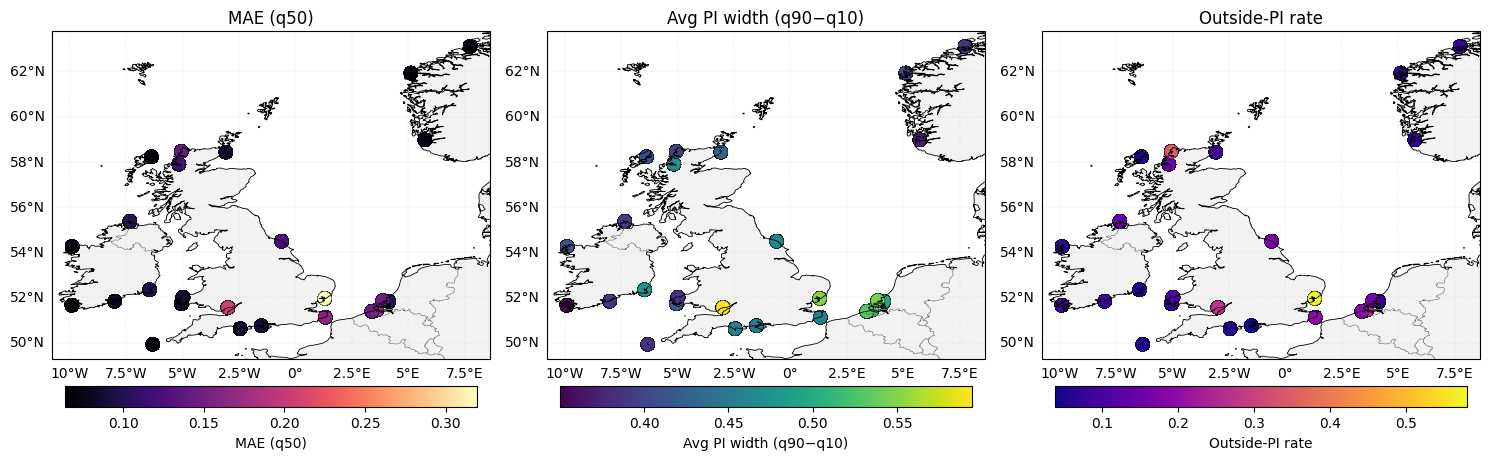

In [65]:

# ============================
# 3) Cartopy maps for metrics
# ============================
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
import numpy as np

def _add_base(ax, extent=None):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.4")
    ax.add_feature(cfeature.LAND, facecolor="0.95")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5, linestyle="--")
    gl.right_labels = False
    gl.top_labels = False
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

def plot_station_metric_map(metrics_geo: pd.DataFrame,
                            metric: str,
                            title: str = None,
                            cmap: str = "viridis",
                            extent=None,
                            s=18):
    """
    Plot one metric as colored station markers on a Cartopy map.
    metrics_geo must have columns: ['station','lat','lon', metric]
    extent: [lon_min, lon_max, lat_min, lat_max] in degrees (optional)
    """
    if metric not in metrics_geo.columns:
        raise ValueError(f"metric '{metric}' not found. Available: {list(metrics_geo.columns)}")

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8.5, 5.8))
    ax = plt.axes(projection=proj)
    _add_base(ax, extent=extent)

    v = metrics_geo[metric].to_numpy()
    norm = Normalize(vmin=np.nanpercentile(v, 2), vmax=np.nanpercentile(v, 98))  # robust scaling

    sc = ax.scatter(metrics_geo["lon"], metrics_geo["lat"],
                    c=v, s=s, cmap=cmap, norm=norm,
                    transform=ccrs.PlateCarree(), edgecolor="k", linewidth=0.2)

    cb = plt.colorbar(sc, ax=ax, orientation="vertical", fraction=0.032, pad=0.02)
    cb.set_label(metric)

    ax.set_title(title or metric)
    plt.tight_layout()
    plt.show()

def plot_all_three_maps(metrics_geo: pd.DataFrame, extent=None):
    """
    Convenience: 3 side-by-side maps for MAE(q50), avg width, and outside rate.
    """
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.2),
                             subplot_kw=dict(projection=proj))

    metrics = [
        ("mae_q50", "MAE (q50)", "magma"),
        ("avg_width", "Avg PI width (q90−q10)", "viridis"),
        ("outside_rate", "Outside-PI rate", "plasma"),
    ]

    for ax, (col, title, cmap) in zip(axes, metrics):
        _add_base(ax, extent=extent)
        v = metrics_geo[col].to_numpy()
        norm = Normalize(vmin=np.nanpercentile(v, 2), vmax=np.nanpercentile(v, 98))
        sc = ax.scatter(metrics_geo["lon"], metrics_geo["lat"],
                        c=v, s=100, cmap=cmap, norm=norm,
                        transform=ccrs.PlateCarree(), edgecolor="k", linewidth=0.2)
        cb = plt.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.046, pad=0.06)
        cb.set_label(title)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

# 1) compute + merge
station_metrics = compute_station_metrics(df)
metrics_geo = pd.merge(
    station_metrics, 
    features_df.rename(columns={"latitude":"lat","longitude":"lon"})[["station","lat","lon"]],
    on="station", how="inner"
)

# 2) Optional: set a geographic extent (lon_min, lon_max, lat_min, lat_max)
#    If your stations are, say, over Europe:
# extent = [-12, 35, 35, 70]
extent = None

# 3) Plot
plot_all_three_maps(metrics_geo, extent=extent)

# Or one at a time:
# plot_station_metric_map(metrics_geo, "mae_q50", "MAE (q50)", cmap="magma", extent=extent)
# plot_station_metric_map(metrics_geo, "avg_width", "Average PI width (q90−q10)", cmap="viridis", extent=extent)
# plot_station_metric_map(metrics_geo, "outside_rate", "Outside-PI rate", cmap="plasma", extent=extent)

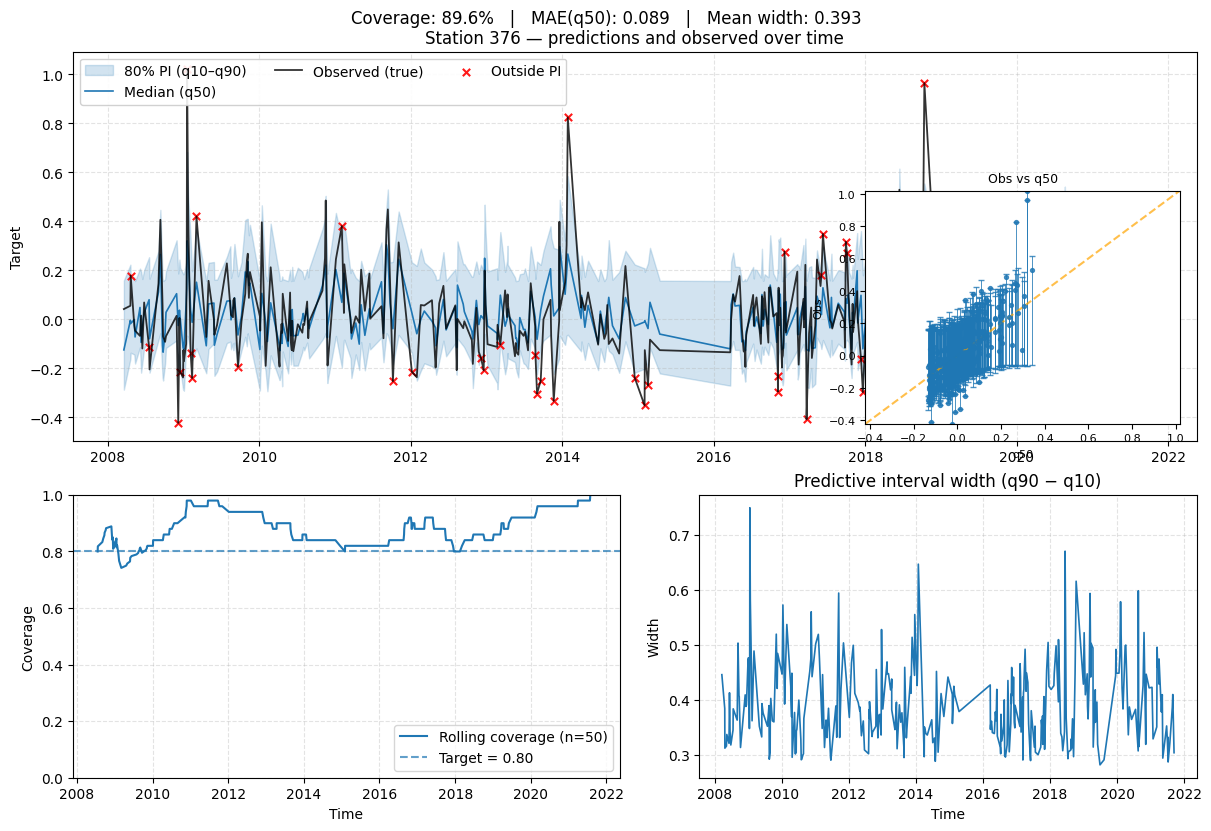

In [ ]:
# ---- Example usage ----
station_id = df["station"].iloc[10]
plot_station_diagnostics(df, station_id, window=50)

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

# ======================================================
# 1️⃣  Compute per-station diagnostics & uncertainty metrics
# ======================================================

def compute_station_uncertainty_metrics(df: pd.DataFrame, alpha: float = 0.2) -> pd.DataFrame:
    """
    Compute per-station metrics:
    - MAE of q50
    - Coverage (PICP)
    - Confidence ratio (coverage / nominal)
    - Average interval width (sharpness)
    - PINAW (normalized width)
    - Interval Score (proper scoring rule)
    - Tail miss rate (missing extremes)
    """
    g = df.copy()
    g["valid_time"] = pd.to_datetime(g["valid_time"])
    g["width"] = (g["pred_q90"] - g["pred_q10"]).clip(lower=0)
    g["abs_err_q50"] = (g["y_true"] - g["pred_q50"]).abs()
    g["inside"] = (g["y_true"] >= g["pred_q10"]) & (g["y_true"] <= g["pred_q90"])

    def station_stats(sub):
        y = sub["y_true"].to_numpy()
        q10 = sub["pred_q10"].to_numpy()
        q50 = sub["pred_q50"].to_numpy()
        q90 = sub["pred_q90"].to_numpy()
        width = sub["width"].to_numpy()
        inside = sub["inside"].to_numpy()

        coverage = np.mean(inside)
        mae_q50 = np.mean(np.abs(y - q50))
        mean_width = np.mean(width)
        pinaw = mean_width / (np.max(y) - np.min(y)) if np.max(y) > np.min(y) else np.nan
        confidence_ratio = coverage / (1 - alpha)

        # Interval Score (proper scoring rule)
        score = (q90 - q10) + (2 / alpha) * (
            (q10 - y) * (y < q10) + (y - q90) * (y > q90)
        )
        interval_score = np.mean(score)

        # Tail miss rate – fraction of extreme obs missed by PI
        abs_dev = np.abs(y - np.median(y))
        threshold = np.percentile(abs_dev, 90)
        tail_miss_rate = np.mean(((y < q10) | (y > q90)) & (abs_dev > threshold))

        return pd.Series(
            dict(
                mae_q50=mae_q50,
                coverage=coverage,
                confidence_ratio=confidence_ratio,
                avg_width=mean_width,
                pinaw=pinaw,
                interval_score=interval_score,
                tail_miss_rate=tail_miss_rate,
                n_obs=len(sub),
            )
        )

    station_metrics = g.groupby("station").apply(station_stats).reset_index()
    return station_metrics


# ======================================================
# 2️⃣  Merge metrics with station coordinates
# ======================================================

def merge_with_features(station_metrics: pd.DataFrame, features_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge station metrics with features_df containing lat/lon columns.
    features_df must contain: ['station', 'lat', 'lon'] or ['station', 'latitude', 'longitude']
    """
    feat = features_df.copy()

    # Normalize naming
    if "latitude" in feat.columns and "lat" not in feat.columns:
        feat = feat.rename(columns={"latitude": "lat"})
    if "longitude" in feat.columns and "lon" not in feat.columns:
        feat = feat.rename(columns={"longitude": "lon"})

    if not {"station", "lat", "lon"}.issubset(feat.columns):
        raise ValueError("features_df must have ['station', 'lat', 'lon'] columns")

    merged = pd.merge(station_metrics, feat[["station", "lat", "lon"]], on="station", how="inner")
    return merged.dropna(subset=["lat", "lon"])


# ======================================================
# 3️⃣  Cartopy base map utilities
# ======================================================

def _add_base(ax, extent=None):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.4")
    ax.add_feature(cfeature.LAND, facecolor="0.93")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5, linestyle="--")
    gl.right_labels = False
    gl.top_labels = False
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())


# ======================================================
# 4️⃣  Generic metric plotter
# ======================================================

def plot_station_metric_map(metrics_geo, metric, title=None, cmap="viridis", extent=None, s=30):
    if metric not in metrics_geo.columns:
        raise ValueError(f"Metric '{metric}' not found. Available: {metrics_geo.columns.tolist()}")

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(8, 5.5))
    ax = plt.axes(projection=proj)
    _add_base(ax, extent)

    vals = metrics_geo[metric].to_numpy()
    norm = Normalize(vmin=np.nanpercentile(vals, 2), vmax=np.nanpercentile(vals, 98))

    sc = ax.scatter(metrics_geo["lon"], metrics_geo["lat"],
                    c=vals, s=s, cmap=cmap, norm=norm,
                    transform=ccrs.PlateCarree(), edgecolor="k", linewidth=0.2)

    cb = plt.colorbar(sc, ax=ax, orientation="vertical", fraction=0.035, pad=0.03)
    cb.set_label(metric)
    ax.set_title(title or metric)
    plt.tight_layout()
    plt.show()


# ======================================================
# 5️⃣  Combined “uncertainty quality” map dashboard
# ======================================================

def plot_uncertainty_dashboard(metrics_geo, extent=None):
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(2, 3, figsize=(16, 8),
                             subplot_kw=dict(projection=proj))
    axes = axes.ravel()

    metric_info = [
        ("mae_q50", "MAE(q50)", "magma"),
        ("avg_width", "Avg PI width", "viridis"),
        ("coverage", "Coverage (empirical)", "cividis"),
        ("confidence_ratio", "Confidence Ratio", "coolwarm"),
        ("interval_score", "Interval Score", "plasma"),
        ("tail_miss_rate", "Tail Miss Rate", "Reds"),
    ]

    for ax, (col, title, cmap) in zip(axes, metric_info):
        _add_base(ax, extent)
        vals = metrics_geo[col].to_numpy()
        norm = Normalize(vmin=np.nanpercentile(vals, 2), vmax=np.nanpercentile(vals, 98))
        sc = ax.scatter(metrics_geo["lon"], metrics_geo["lat"],
                        c=vals, s=22, cmap=cmap, norm=norm,
                        transform=ccrs.PlateCarree(), edgecolor="k", linewidth=0.2)
        cb = plt.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.045, pad=0.05)
        cb.set_label(title)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()


station_metrics = compute_station_uncertainty_metrics(df)
metrics_geo = merge_with_features(station_metrics, features_df)

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_3607/3305599166.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_metrics = g.groupby("station").apply(station_stats).reset_index()


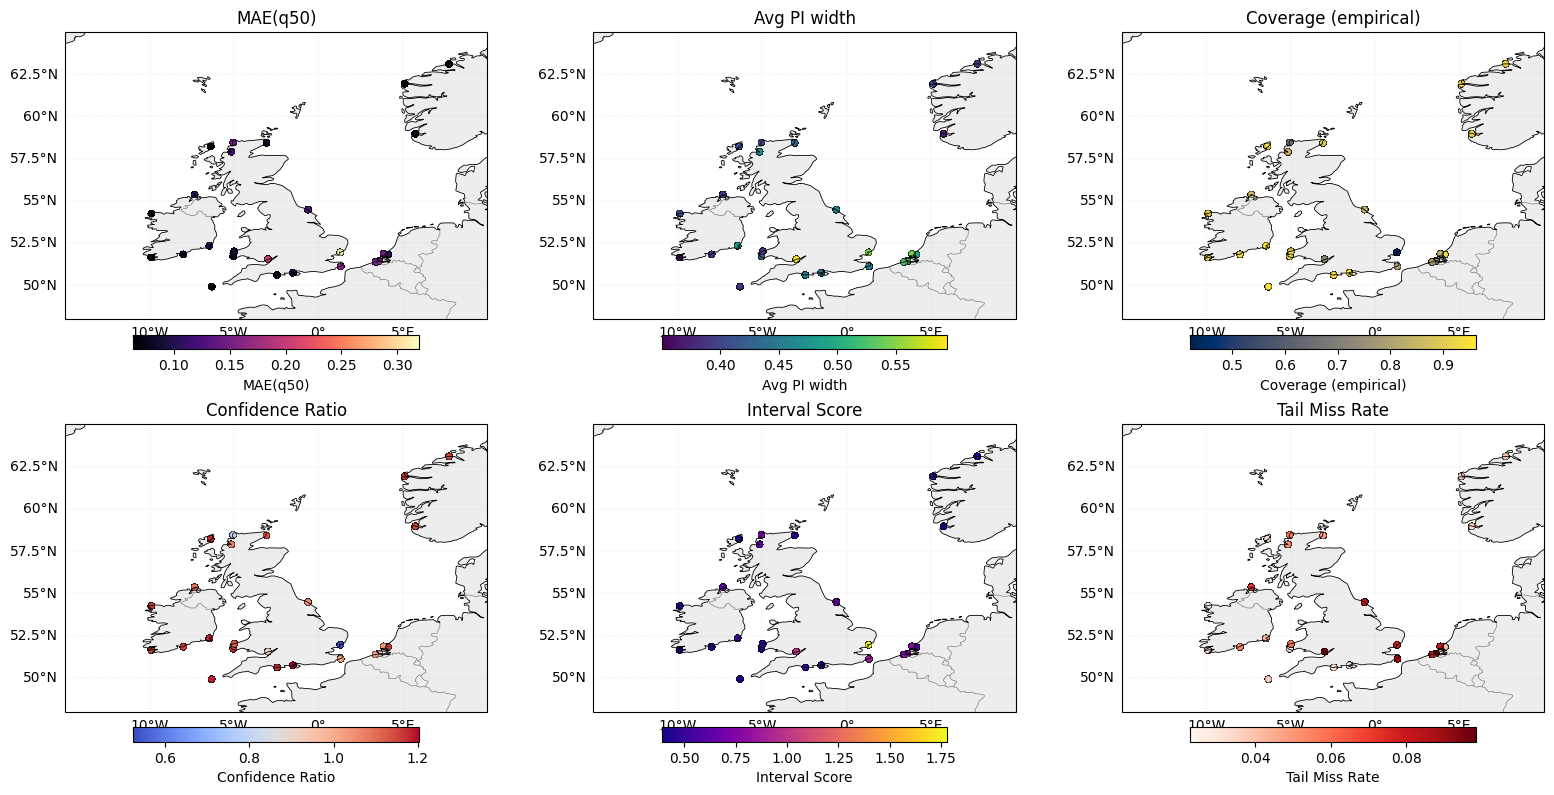

In [70]:
plot_uncertainty_dashboard(metrics_geo, extent=[-15, 10, 48, 65])

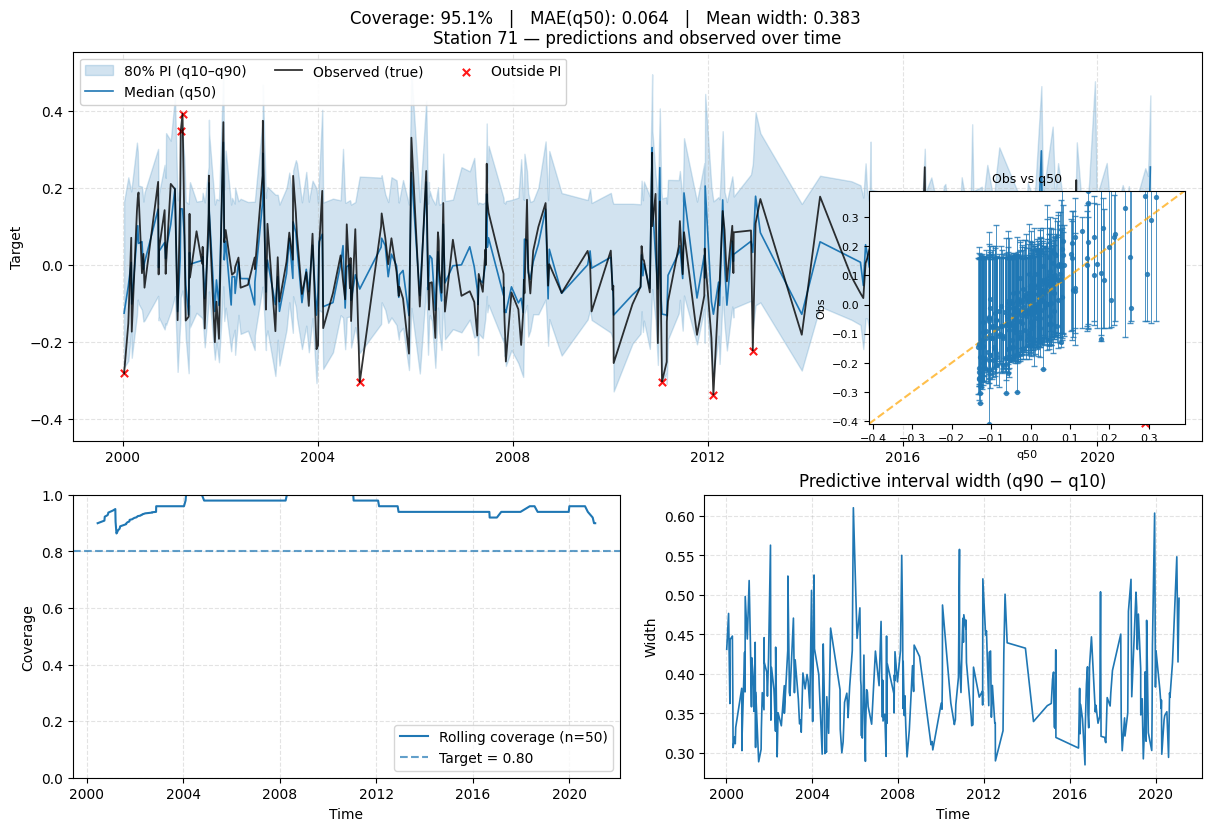

In [58]:
# ---- Example usage ----
station_id = df["station"].iloc[9]
plot_station_diagnostics(df, station_id, window=50)


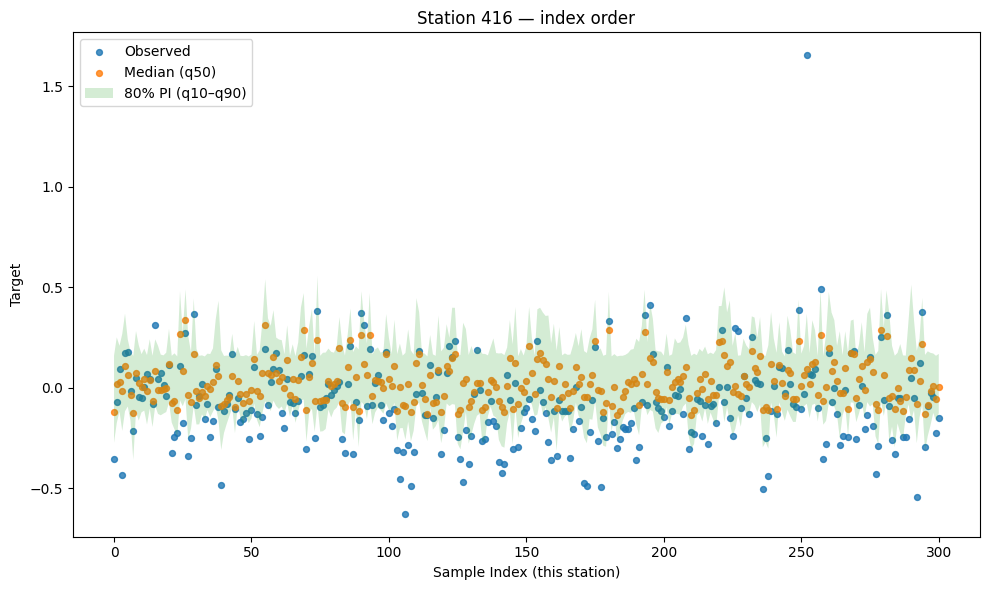

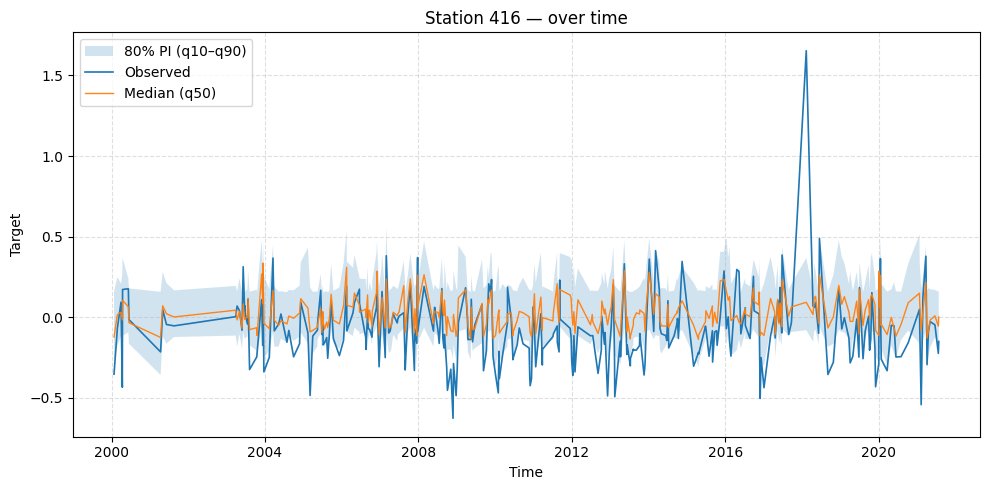

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Prep a tidy test dataframe with quantiles ---
# (If starting fresh) out = pd.read_parquet("test_predictions.parquet")
df = out.loc[m_test, ["station", "valid_time", target, "pred_q10", "pred_q50", "pred_q90"]].copy()
df = df.rename(columns={target: "y_true"})
df["valid_time"] = pd.to_datetime(df["valid_time"])

# ---------- Utilities ----------
def get_station_data(station_id):
    g = df[df["station"] == station_id].sort_values("valid_time")
    if g.empty:
        raise ValueError(f"No test rows for station {station_id}")
    y_true = g["y_true"].to_numpy()
    preds = {
        0.1: g["pred_q10"].to_numpy(),
        0.5: g["pred_q50"].to_numpy(),
        0.9: g["pred_q90"].to_numpy(),
    }
    t = g["valid_time"].to_numpy()
    # anti-crossing safeguard
    preds[0.5] = np.maximum(preds[0.1], preds[0.5])
    preds[0.9] = np.maximum(preds[0.5], preds[0.9])
    return t, y_true, preds

def plot_quantile_intervals_index(y_true, preds, title=None):
    q10, q50, q90 = preds[0.1], preds[0.5], preds[0.9]
    idx = np.arange(len(y_true))
    plt.figure(figsize=(10, 6))
    plt.scatter(idx, y_true, s=18, alpha=0.8, label="Observed")
    plt.scatter(idx, q50,  s=18, alpha=0.8, label="Median (q50)")
    plt.fill_between(idx, q10, q90, alpha=0.2, label="80% PI (q10–q90)")
    plt.xlabel("Sample Index (this station)")
    plt.ylabel("Target")
    plt.title(title or "Station predictions (index order)")
    plt.legend(); plt.tight_layout(); plt.show()

def plot_quantile_intervals_time(t, y_true, preds, title=None):
    q10, q50, q90 = preds[0.1], preds[0.5], preds[0.9]
    plt.figure(figsize=(10, 5))
    plt.fill_between(t, q10, q90, alpha=0.20, label="80% PI (q10–q90)")
    plt.plot(t, y_true, lw=1.2, label="Observed")
    plt.plot(t, q50,  lw=1.0, alpha=0.95, label="Median (q50)")
    plt.xlabel("Time"); plt.ylabel("Target")
    plt.title(title or "Station predictions (time axis)")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# ---------- Example usage ----------
station_id = df["station"].iloc[0]  # pick one
t, y_true, preds = get_station_data(station_id)

# Index-based ribbon (like your original scatter/index plot)
plot_quantile_intervals_index(y_true, preds, title=f"Station {station_id} — index order")

# True time-series ribbon
plot_quantile_intervals_time(t, y_true, preds, title=f"Station {station_id} — over time")


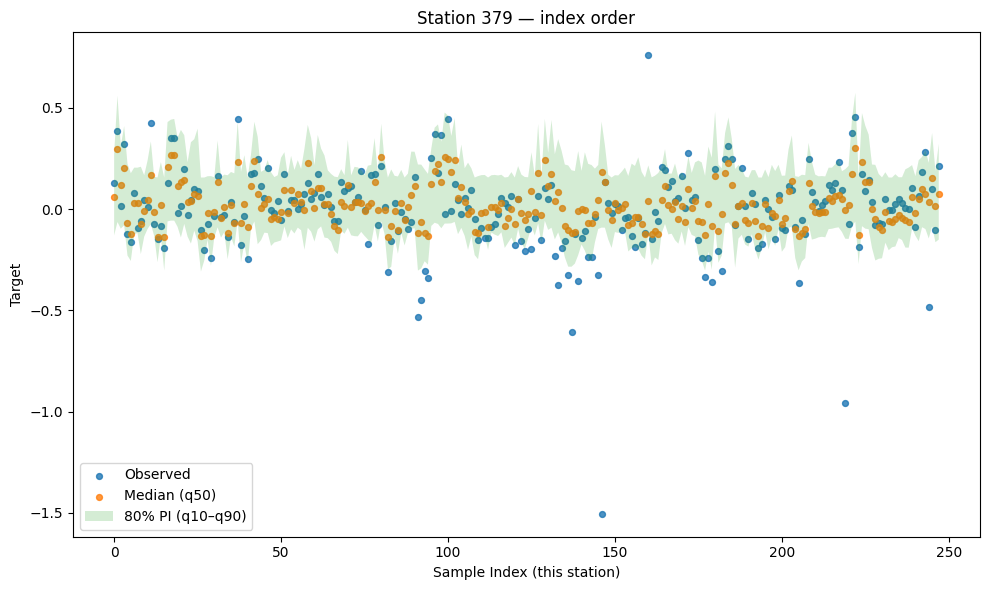

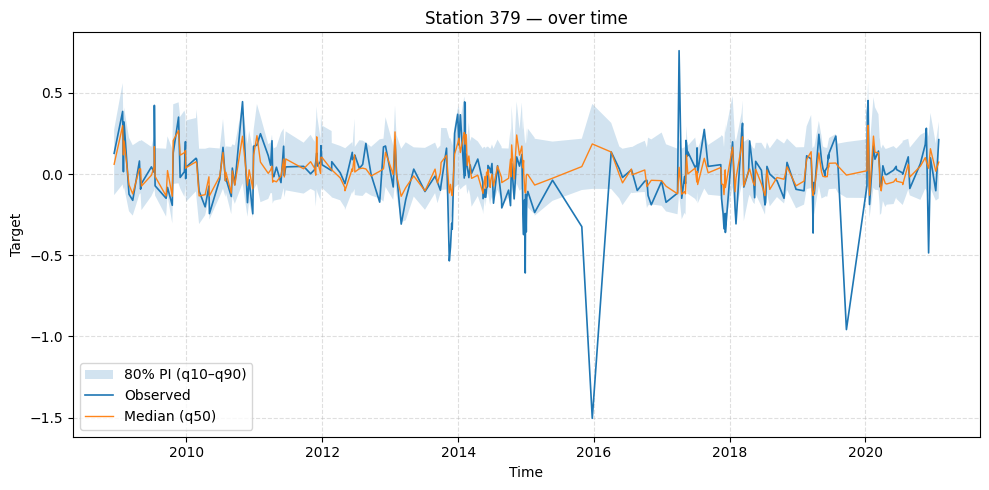

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Prep a tidy test dataframe with quantiles ---
# (If starting fresh) out = pd.read_parquet("test_predictions.parquet")
df = out.loc[m_test, ["station", "valid_time", target, "pred_q10", "pred_q50", "pred_q90"]].copy()
df = df.rename(columns={target: "y_true"})
df["valid_time"] = pd.to_datetime(df["valid_time"])

# ---------- Utilities ----------
def get_station_data(station_id):
    g = df[df["station"] == station_id].sort_values("valid_time")
    if g.empty:
        raise ValueError(f"No test rows for station {station_id}")
    y_true = g["y_true"].to_numpy()
    preds = {
        0.1: g["pred_q10"].to_numpy(),
        0.5: g["pred_q50"].to_numpy(),
        0.9: g["pred_q90"].to_numpy(),
    }
    t = g["valid_time"].to_numpy()
    # anti-crossing safeguard
    preds[0.5] = np.maximum(preds[0.1], preds[0.5])
    preds[0.9] = np.maximum(preds[0.5], preds[0.9])
    return t, y_true, preds

def plot_quantile_intervals_index(y_true, preds, title=None):
    q10, q50, q90 = preds[0.1], preds[0.5], preds[0.9]
    idx = np.arange(len(y_true))
    plt.figure(figsize=(10, 6))
    plt.scatter(idx, y_true, s=18, alpha=0.8, label="Observed")
    plt.scatter(idx, q50,  s=18, alpha=0.8, label="Median (q50)")
    plt.fill_between(idx, q10, q90, alpha=0.2, label="80% PI (q10–q90)")
    plt.xlabel("Sample Index (this station)")
    plt.ylabel("Target")
    plt.title(title or "Station predictions (index order)")
    plt.legend(); plt.tight_layout(); plt.show()

def plot_quantile_intervals_time(t, y_true, preds, title=None):
    q10, q50, q90 = preds[0.1], preds[0.5], preds[0.9]
    plt.figure(figsize=(10, 5))
    plt.fill_between(t, q10, q90, alpha=0.20, label="80% PI (q10–q90)")
    plt.plot(t, y_true, lw=1.2, label="Observed")
    plt.plot(t, q50,  lw=1.0, alpha=0.95, label="Median (q50)")
    plt.xlabel("Time"); plt.ylabel("Target")
    plt.title(title or "Station predictions (time axis)")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# ---------- Example usage ----------
station_id = df["station"].iloc[1]  # pick one
t, y_true, preds = get_station_data(station_id)

# Index-based ribbon (like your original scatter/index plot)
plot_quantile_intervals_index(y_true, preds, title=f"Station {station_id} — index order")

# True time-series ribbon
plot_quantile_intervals_time(t, y_true, preds, title=f"Station {station_id} — over time")

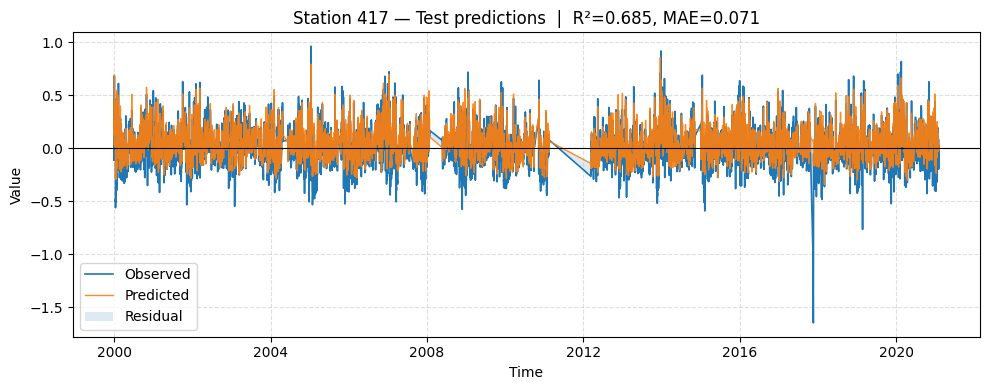

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[32])

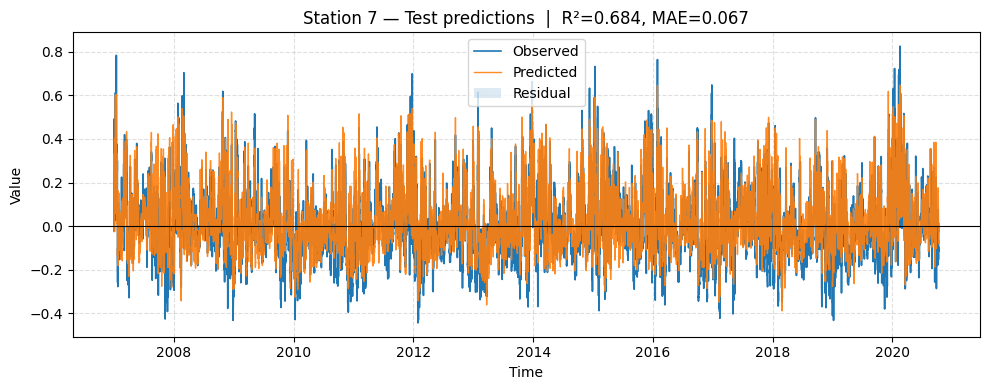

In [28]:
plot_station_residuals(preds['station'].iloc[6])

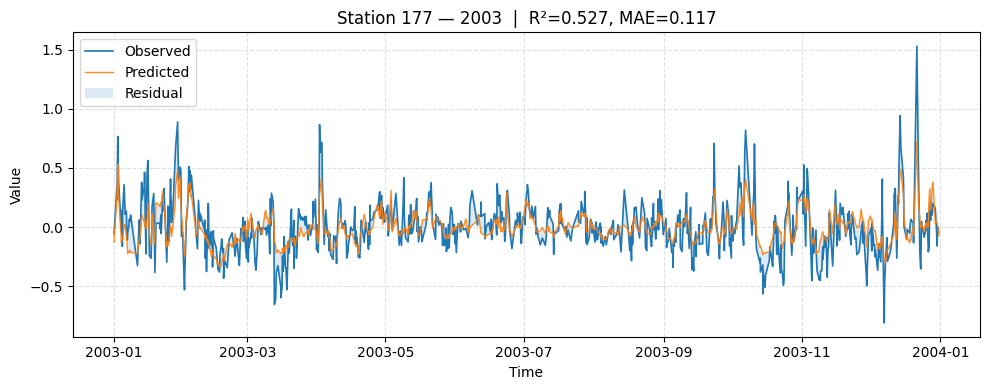

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[0], year=2003)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_3607/4089206154.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: r2_score(g["y_true"], g["y_pred"]) if len(g) > 1 else np.nan)


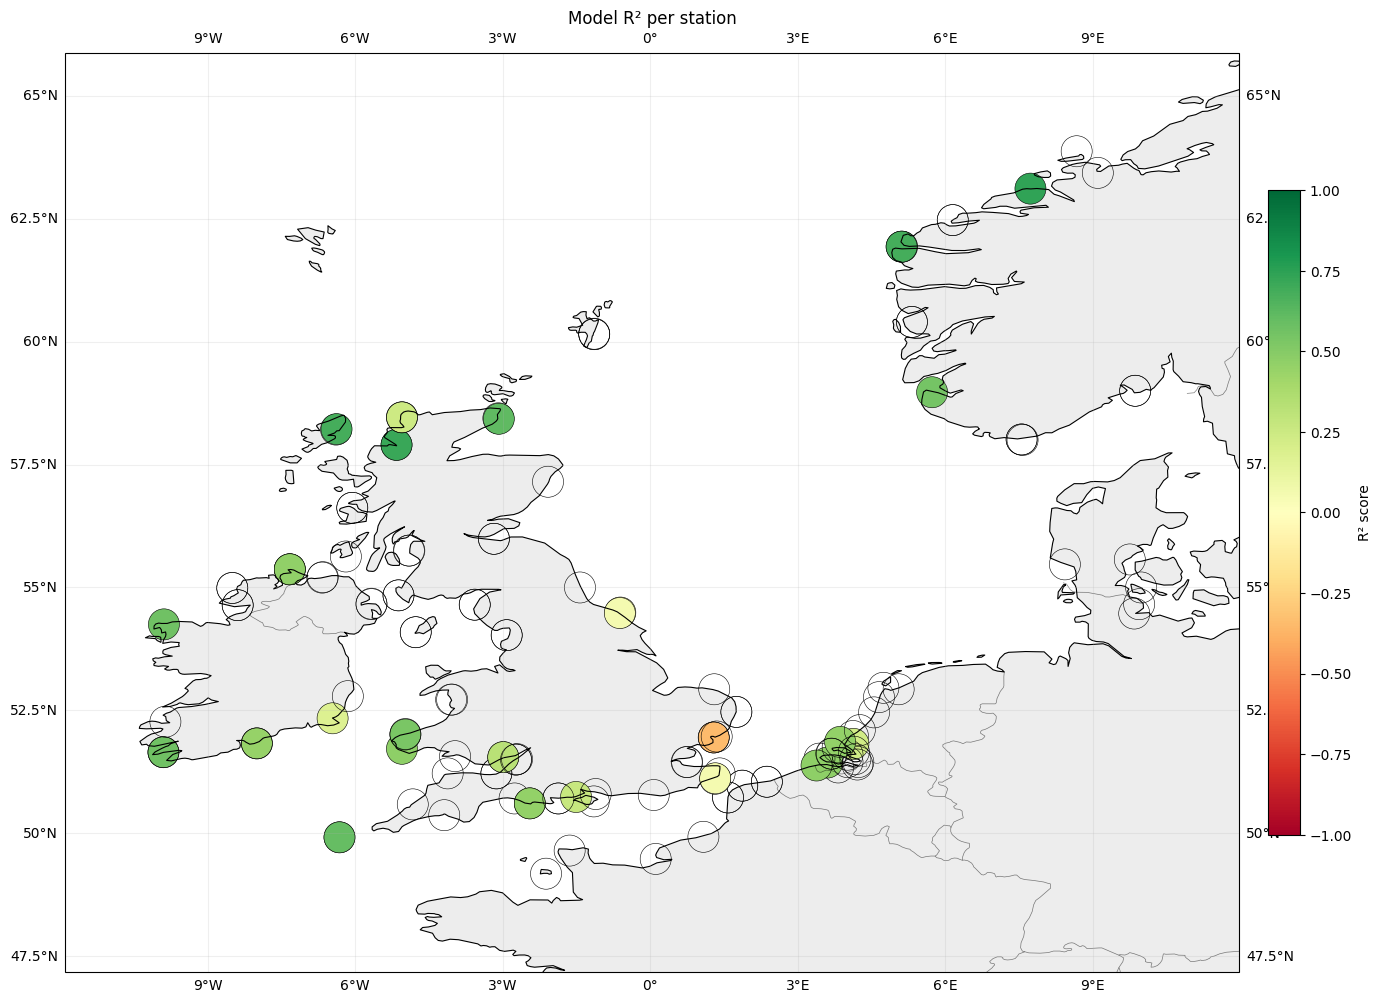

In [30]:
from sklearn.metrics import r2_score

# Compute R² per station
station_r2 = (
    preds.groupby("station")
         .apply(lambda g: r2_score(g["y_true"], g["y_pred"]) if len(g) > 1 else np.nan)
         .rename("r2")
         .reset_index()
         .sort_values("r2")
)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Get unique station coordinates ---
station_coords = merged.groupby("station")[["latitude","longitude"]].first().reset_index()

# --- Join R² scores ---
station_scores = station_coords.merge(station_r2, on="station", how="left")

# --- Plot ---
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Base map
ax.set_extent([
    station_scores["longitude"].min() - 2,
    station_scores["longitude"].max() + 2,
    station_scores["latitude"].min() - 2,
    station_scores["latitude"].max() + 2
])
ax.coastlines(resolution="50m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, alpha=0.2)

# Scatter stations colored by R²
sc = ax.scatter(
    station_scores["longitude"],
    station_scores["latitude"],
    c=station_scores["r2"],
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    s=500,
    edgecolor="k",
    linewidth=0.4,
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("R² score")

plt.title("Model R² per station")
plt.tight_layout()
plt.show()
